In [2]:
import albumentations as A
import cv2
import numpy as np
from albumentations.pytorch import ToTensorV2
import imageio
from datasets.dataset_synthia import *
from datasets.dataset_cityscapes import *
import matplotlib.pyplot as plt
import utils


trainid_to_trainid = {
        0: ignore_label,  # void
        1: 9,            # sky
        2: 2,             # building
        3: 0,             # road
        4: 1,             # sidewalk
        5: 4,             # fence
        6: 8,             # vegetation
        7: 5,             # pole
        8: 12,            # car
        9: 7,             # traffic sign
        10: 10,           # pedestrian - person
        11: 15,           # bicycle
        12: 14,           # motorcycle
        13: ignore_label, # parking-slot
        14: ignore_label, # road-work
        15: 6,            # traffic light
        16: ignore_label, # terrain - not present!
        17: 11,           # rider
        18: ignore_label, # truck - not present!
        19: 13,           # bus
        20: ignore_label, # train - - not present!
        21: 3,            # wall
        22: ignore_label  # Lanemarking
        }


In [2]:
additional_targets = {'mask':'mask'}

transform_synthia_train = A.Compose([
                # A.RandomCrop(width=640, height=380),
                A.RandomResizedCrop(size=(380, 640), scale=(0.8, 1.0), ratio=(0.75, 1.33)),
                A.HorizontalFlip(p=0.5),
                A.OneOf([
                    A.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.2, hue=0.05),
                    A.RandomBrightnessContrast(brightness_limit=(-0.15, 0.3), contrast_limit=0.3)
                ], p=0.7),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std=(0.229, 0.224, 0.225)),
                ToTensorV2(),
            ], additional_targets=additional_targets)

transform_synthia_val = A.Compose([
                A.Resize(380, 640),
                A.Normalize(mean=(0.485, 0.456, 0.406),
                            std=(0.229, 0.224, 0.225)),
                ToTensorV2(),
            ], additional_targets=additional_targets)


transform_cs_val = A.Compose([
            A.Resize(512, 1024),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ], additional_targets=additional_targets
)

In [5]:
image_path = "./synthia/RGB/0000321.png"
mask_path = "./synthia/GT/Labels/0000321.png" # Often PNG format

# Read image (convert to RGB)
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask = np.asarray(imageio.imread(mask_path, format='PNG-FI'))[:, :, 0]
# mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

print(f"Loaded image shape: {image.shape}, dtype: {image.dtype}")
print(f"Loaded mask shape: {mask.shape}, dtype: {mask.dtype}")

mask_copy = mask.copy()
for k, v in trainid_to_trainid.items():
    mask_copy[mask == k] = v

mask = mask_copy
print(np.unique(mask))

Loaded image shape: (760, 1280, 3), dtype: uint8
Loaded mask shape: (760, 1280), dtype: uint16
[  0   1   2   3   4   5   8   9  10  11  12  14  15 255]


/tmp/ipykernel_106650/897820685.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = np.asarray(imageio.imread(mask_path, format='PNG-FI'))[:, :, 0]
/root/venv-synth/lib/python3.12/site-packages/imageio/core/util.py:508: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [6]:
# apply the transformation synchronized
augmented = transform_synthia_train(image=image, mask=mask)

augmented_image = augmented['image']
augmented_mask = augmented['mask']

print(f"Augmented image shape: {augmented_image.shape}, dtype: {augmented_image.dtype}")
print(f"Augmented mask shape: {augmented_mask.shape}, dtype: {augmented_mask.dtype}")

Augmented image shape: torch.Size([3, 380, 640]), dtype: torch.float32
Augmented mask shape: torch.Size([380, 640]), dtype: torch.uint16


In [7]:
image_cs_path = "./cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png"
mask_cs_path = "./cityscapes/gtFine/val/frankfurt/frankfurt_000000_000294_gtFine_labelIds.png" # Often PNG format

# Read image (convert to RGB)
image_cs = cv2.imread(image_cs_path)
image_cs = cv2.cvtColor(image_cs, cv2.COLOR_BGR2RGB)
# mask_cs = np.asarray(imageio.imread(mask_path, format='PNG-FI'))[:, :, 0]
mask_cs = cv2.imread(mask_cs_path, cv2.IMREAD_GRAYSCALE)

print(f"Loaded image shape: {image_cs.shape}, dtype: {image_cs.dtype}")
print(f"Loaded mask shape: {mask_cs.shape}, dtype: {mask_cs.dtype}")

Loaded image shape: (1024, 2048, 3), dtype: uint8
Loaded mask shape: (1024, 2048), dtype: uint8


In [8]:
print(np.unique(mask_cs))

[ 1  2  3  4  7  8 11 13 17 20 21 23 24 26]


In [9]:
# apply the transformation synchronized
augmented = transform_cs_val(image=image_cs, mask=mask_cs)

augmented_image_cs = augmented['image']
augmented_mask_cs = augmented['mask']

print(f"Augmented image shape: {augmented_image_cs.shape}, dtype: {augmented_image_cs.dtype}")
print(f"Augmented mask shape: {augmented_mask_cs.shape}, dtype: {augmented_mask_cs.dtype}")

Augmented image shape: torch.Size([3, 512, 1024]), dtype: torch.float32
Augmented mask shape: torch.Size([512, 1024]), dtype: torch.uint8


In [49]:
np.unique(augmented_mask_cs)

array([ 1,  2,  3,  4,  7,  8, 11, 13, 17, 20, 21, 23, 24, 26],
      dtype=uint8)

In [3]:
# define the dataloader
BATCH_SIZE = 8
USE_SYNTHIA_SHAPES = False

source_train_data_loader = utils.get_dataloader_from_dataset('synthia', 'synthia', 'train', batch_size=BATCH_SIZE, shuffle=True, use_synthia_shapes=USE_SYNTHIA_SHAPES)
source_val_data_loader = utils.get_dataloader_from_dataset('synthia', 'synthia', 'val', batch_size=1, shuffle=False)

target_val_data_loader = utils.get_dataloader_from_dataset('cityscapes', 'cityscapes', 'val', batch_size=1, shuffle=False)

dataset_synthia_train = Synthia(root_dir='./synthia', split='train', transform=utils.get_augmentation('synthia', 'train'))
dataset_synthia_val = Synthia(root_dir='./synthia', split='val', transform=utils.get_augmentation('synthia', 'val'))
dataset_cs_val = CityScapes(root_dir='./cityscapes', split='val', transform=utils.get_augmentation('cityscapes', ''))

print(dataset_cs_val.transform)

Use synthia as the source dataset
Use synthia as the source dataset
Use cityscapes as the target dataset
Compose([
  Resize(p=1.0, area_for_downscale=None, height=512, interpolation=1, mask_interpolation=0, width=1024),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


before, unique labels: [  0   1   2   3   4   5   7   8   9  10  11  12  13  14  15 255]
before: {0: 180300, 1: 111769, 2: 197245, 3: 6, 4: 73, 5: 4750, 7: 980, 8: 270202, 9: 15922, 10: 34321, 11: 6327, 12: 66904, 13: 10322, 14: 1248, 15: 4945, 255: 67486}
after: {0: 180300, 1: 111769, 2: 197245, 3: 6, 4: 73, 5: 4750, 7: 980, 8: 270202, 9: 15922, 10: 34321, 11: 6327, 12: 66904, 13: 10322, 14: 1248, 15: 4945, 255: 67486}
after: {0: 34219, 1: 32766, 2: 45896, 3: 1, 4: 26, 5: 1417, 7: 322, 8: 74697, 9: 3277, 10: 10039, 11: 50, 12: 20337, 13: 9, 14: 401, 15: 114, 255: 19629}
after: {0: 180300, 1: 111769, 2: 197245, 3: 6, 4: 73, 5: 4750, 7: 980, 8: 270202, 9: 15922, 10: 34321, 11: 6327, 12: 66904, 13: 10322, 14: 1248, 15: 4945, 255: 67486}
after: {0: 180300, 1: 111769, 2: 197245, 3: 6, 4: 73, 5: 4750, 7: 980, 8: 270202, 9: 15922, 10: 34321, 11: 6327, 12: 66904, 13: 10322, 14: 1248, 15: 4945, 255: 67486}
after: {0: 180300, 1: 111769, 2: 197245, 3: 6, 4: 73, 5: 4750, 7: 980, 8: 270202, 9: 159

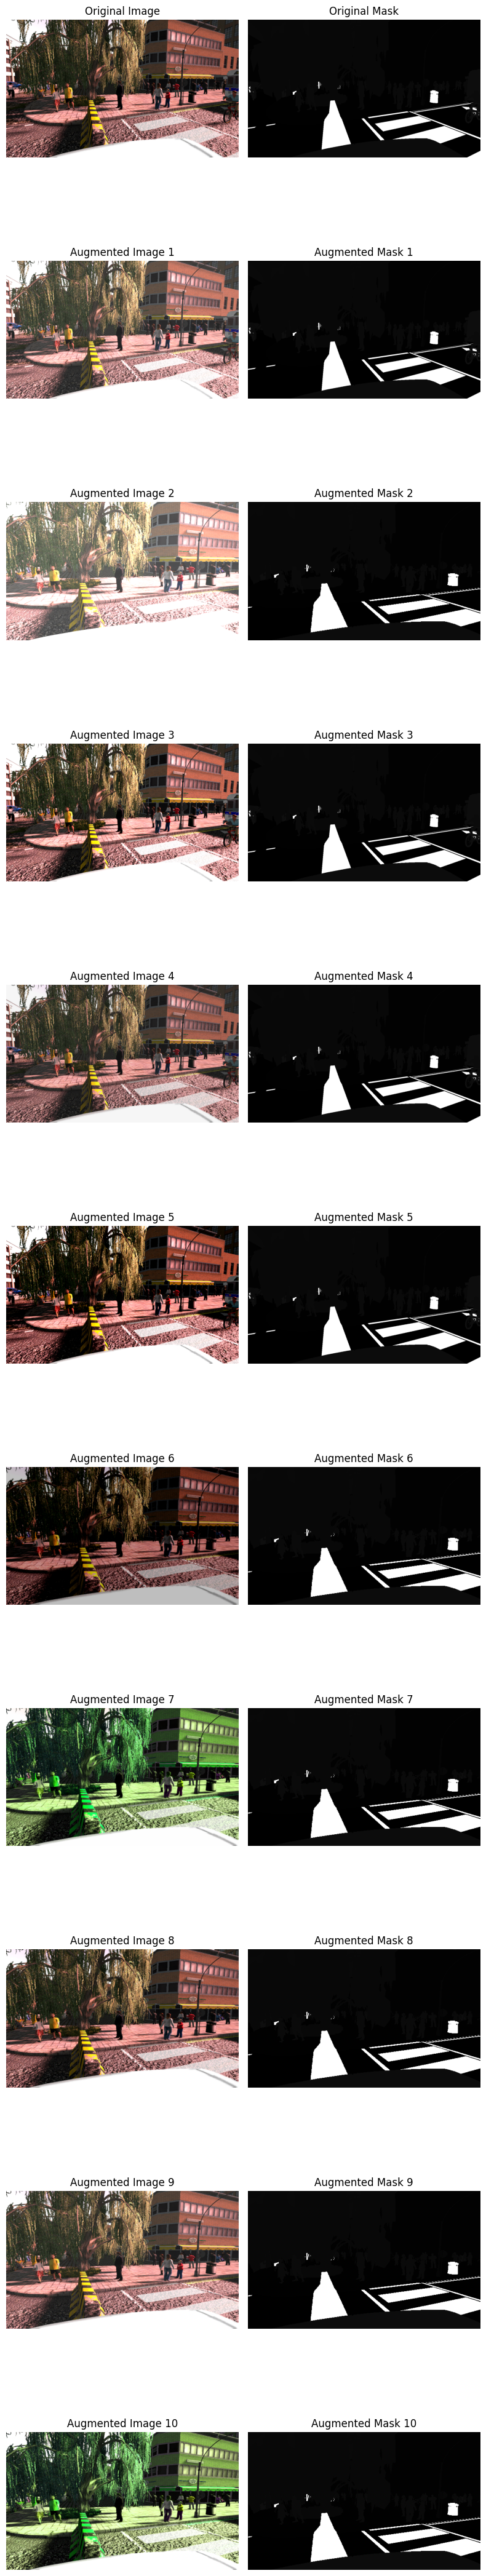

In [6]:
# Simple function to overlay mask on image for visualization
def overlay_mask(image, mask, alpha=0.5, color=(0, 1, 0)): # Green overlay
    # Convert mask to 3 channels if needed, ensure boolean type
    mask_overlay = np.zeros_like(image, dtype=np.uint8)
    # Create a color overlay where mask is > 0
    mask_overlay[mask > 0] = (np.array(color) * 255).astype(np.uint8)

    # Blend image and overlay
    overlayed_image = cv2.addWeighted(image, 1, mask_overlay, alpha, 0)
    return overlayed_image


def visualize_segmentation(dataset, idx=0, samples=3):
    # Make a copy of the transform list to modify for visualization
    if isinstance(dataset.transform, A.Compose):
        vis_transform_list = [
            t for t in dataset.transform
            if not isinstance(t, (A.Normalize, A.ToTensorV2))
        ]
        vis_transform = A.Compose(vis_transform_list)
    else:
        print("Warning: Could not automatically strip Normalize/ToTensor for visualization.")
        vis_transform = dataset.transform

    figure, ax = plt.subplots(samples + 1, 2, figsize=(8, 4 * (samples + 1)))

    # --- Get the original image and mask --- #
    original_transform = dataset.transform
    dataset.transform = None # Temporarily disable for raw data access
    image, mask = dataset[idx]
    print("before, unique labels:", np.unique(mask))
    unique_labels, counts = np.unique(mask, return_counts=True)
    print("before:", dict(zip(unique_labels, counts)))
    dataset.transform = original_transform # Restore

    # Display original
    ax[0, 0].imshow(image)
    ax[0, 0].set_title("Original Image")
    ax[0, 0].axis("off")
    ax[0, 1].imshow(mask, cmap='gray') # Show mask directly
    ax[0, 1].set_title("Original Mask")
    ax[0, 1].axis("off")
    # ax[0, 1].imshow(overlay_mask(image, mask)) # Or show overlay
    # ax[0, 1].set_title("Original Overlay")

    # --- Apply and display augmented versions --- #
    for i in range(samples):
        # Apply the visualization transform
        if vis_transform:
            augmented = vis_transform(image=image, mask=mask)
            aug_image = augmented['image']
            aug_mask = augmented['mask']
            aug_unique_labels, aug_counts = np.unique(aug_mask, return_counts=True)
            print("after:", dict(zip(aug_unique_labels, aug_counts)))
        else:
            aug_image, aug_mask = image, mask # Should not happen normally

       
        
        # Display augmented image and mask
        ax[i + 1, 0].imshow(aug_image)
        ax[i + 1, 0].set_title(f"Augmented Image {i+1}")
        ax[i + 1, 0].axis("off")

        ax[i + 1, 1].imshow(aug_mask, cmap='gray') # Show mask directly
        ax[i + 1, 1].set_title(f"Augmented Mask {i+1}")
        ax[i + 1, 1].axis("off")
        # ax[i+1, 1].imshow(overlay_mask(aug_image, aug_mask)) # Or show overlay
        # ax[i+1, 1].set_title(f"Augmented Overlay {i+1}")


    plt.tight_layout()
    plt.show()


dataset_synthia_train.transform = A.Compose([
  A.RandomResizedCrop(p=0.5, area_for_downscale=None, interpolation=1, mask_interpolation=0, ratio=(0.75, 1.33), scale=(0.8, 1.0), size=(380, 640)),
  #A.RandomCrop(width=640, height=380),
  # A.HorizontalFlip(p=0.5),
  A.OneOf([
    A.ColorJitter(p=0.5, brightness=(0.7, 1.3), contrast=(0.8, 1.2), hue=(-0.25, 0.25), saturation=(0.8, 1.2)),
    A.RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.15, 0.3), contrast_limit=(-0.3, 0.3), ensure_safe_range=False),
  ], p=0.7),
  A.GaussianBlur(p=0.2, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
  A.Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  A.ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={'mask': 'mask'}, is_check_shapes=True)


# print(dataset_cs_val.transform)

visualize_segmentation(dataset_synthia_train, idx=338, samples=10)

In [68]:
print(dataset_synthia_train.transform)

Compose([
  RandomResizedCrop(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, ratio=(0.75, 1.33), scale=(0.8, 1.0), size=(380, 640)),
  HorizontalFlip(p=0.5),
  OneOf([
    ColorJitter(p=0.5, brightness=(0.7, 1.3), contrast=(0.8, 1.2), hue=(-0.05, 0.05), saturation=(0.8, 1.2)),
    RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.15, 0.3), contrast_limit=(-0.3, 0.3), ensure_safe_range=False),
  ], p=0.7),
  GaussianBlur(p=0.2, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={'mask': 'mask'}, is_check_shapes=True)
